In [1]:
# %matplotlib inline
import numpy as np
import torch
import torch.optim as optim

torch.set_printoptions(edgeitems=2, linewidth=75)

In [2]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # <1>
t_u = torch.tensor(t_u).unsqueeze(1) # <1>

t_u.shape

torch.Size([11, 1])

In [3]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 3,  5,  9,  2,  8, 10,  0,  6,  1]), tensor([7, 4]))

In [4]:
t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [5]:
import torch.nn as nn

linear_model = nn.Linear(1, 1) # <1>
linear_model(t_un_val)

tensor([[1.1713],
        [2.5991]], grad_fn=<AddmmBackward0>)

In [10]:
linear_model.weight

Parameter containing:
tensor([[0.4138]], requires_grad=True)

In [11]:
linear_model.bias

Parameter containing:
tensor([0.2691], requires_grad=True)

In [12]:
x = torch.ones(1)
linear_model(x)

tensor([0.6830], grad_fn=<ViewBackward0>)

In [13]:
x = torch.ones(10, 1)
linear_model(x)

tensor([[0.6830],
        [0.6830],
        [0.6830],
        [0.6830],
        [0.6830],
        [0.6830],
        [0.6830],
        [0.6830],
        [0.6830],
        [0.6830]], grad_fn=<AddmmBackward0>)

In [14]:
linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(
    linear_model.parameters(), # <2>
    lr=1e-2)

In [15]:
linear_model.parameters()

<generator object Module.parameters at 0x78e24b9bbd80>

In [16]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[-0.1462]], requires_grad=True),
 Parameter containing:
 tensor([-0.6858], requires_grad=True)]

In [17]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) # <1>
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) # <1>
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() # <2>
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")


In [18]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 3000, 
    optimizer = optimizer,
    model = linear_model,
    loss_fn = loss_fn,
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 132.6297, Validation loss 44.5694
Epoch 1000, Training loss 4.7717, Validation loss 2.8998
Epoch 2000, Training loss 2.8672, Validation loss 3.3001
Epoch 3000, Training loss 2.7098, Validation loss 4.6099

Parameter containing:
tensor([[5.5904]], requires_grad=True)
Parameter containing:
tensor([-18.4576], requires_grad=True)


In [19]:
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 3000, 
    optimizer = optimizer,
    model = linear_model,
    loss_fn = nn.MSELoss(), # <1>
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 335.9256, Validation loss 113.9809
Epoch 1000, Training loss 4.5316, Validation loss 2.6859
Epoch 2000, Training loss 2.8474, Validation loss 3.3892
Epoch 3000, Training loss 2.7082, Validation loss 4.6480

Parameter containing:
tensor([[5.5952]], requires_grad=True)
Parameter containing:
tensor([-18.4856], requires_grad=True)


In [20]:
seq_model = nn.Sequential(
            nn.Linear(1, 13), # <1>
            nn.Tanh(),
            nn.Linear(13, 1)) # <2>
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [21]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [22]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [27]:
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [28]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [29]:
seq_model.output_linear.bias

Parameter containing:
tensor([-0.0736], requires_grad=True)

In [30]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3) # <1>

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)
    
print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 225.4792, Validation loss 72.5867
Epoch 1000, Training loss 5.9038, Validation loss 2.8897
Epoch 2000, Training loss 4.5329, Validation loss 0.3121
Epoch 3000, Training loss 3.0236, Validation loss 0.1847
Epoch 4000, Training loss 2.4009, Validation loss 0.7032
Epoch 5000, Training loss 2.2289, Validation loss 1.1607
output tensor([[-2.5554],
        [12.9609]], grad_fn=<AddmmBackward0>)
answer tensor([[-4.],
        [11.]])
hidden tensor([[ 1.4878e+01],
        [-1.5042e+01],
        [ 1.9753e-01],
        [ 9.9690e+00],
        [-1.6043e+01],
        [-2.1822e-01],
        [-3.0854e-03],
        [ 9.1900e+00]])


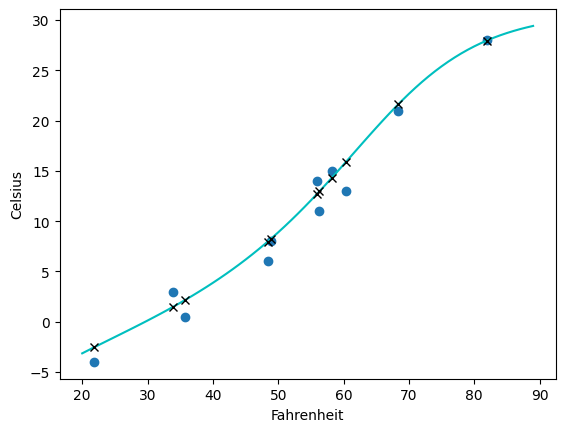

In [32]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure() # dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')


Epoch 1, Training loss 206.0357, Validation loss 66.6682
Epoch 1000, Training loss 103.0628, Validation loss 49.7238
Epoch 2000, Training loss 56.0911, Validation loss 11.2278
Epoch 3000, Training loss 29.7943, Validation loss 2.0040
Epoch 4000, Training loss 15.9896, Validation loss 6.0734
Epoch 5000, Training loss 8.7296, Validation loss 10.9514
Epoch 6000, Training loss 4.9641, Validation loss 11.7675
Epoch 7000, Training loss 2.9507, Validation loss 11.9658
Epoch 8000, Training loss 1.9819, Validation loss 13.0499
Epoch 9000, Training loss 1.5644, Validation loss 14.6723
Epoch 10000, Training loss 1.3917, Validation loss 16.0031


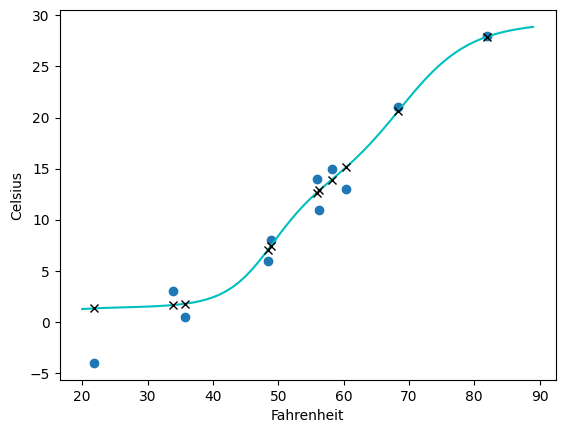

In [41]:
# Exercises here!

neuron_count = 5

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, neuron_count)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(neuron_count, 1))
]))

# optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)
optimizer = optim.Adam(seq_model.parameters(), lr=1e-3)

training_loop(
    n_epochs = 10_000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure() #dpi=150)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')


In [42]:
# WINE NN

In [58]:
wine_path = "../data/p1ch4/tabular-wine/winequality-white.csv"
wine_data = np.loadtxt(wine_path, dtype=np.float32, delimiter=";", skiprows=1)
wine_data

array([[ 7.  ,  0.27,  0.36, ...,  0.45,  8.8 ,  6.  ],
       [ 6.3 ,  0.3 ,  0.34, ...,  0.49,  9.5 ,  6.  ],
       [ 8.1 ,  0.28,  0.4 , ...,  0.44, 10.1 ,  6.  ],
       ...,
       [ 6.5 ,  0.24,  0.19, ...,  0.46,  9.4 ,  6.  ],
       [ 5.5 ,  0.29,  0.3 , ...,  0.38, 12.8 ,  7.  ],
       [ 6.  ,  0.21,  0.38, ...,  0.32, 11.8 ,  6.  ]], dtype=float32)

In [59]:
wine_data.shape

(4898, 12)

In [100]:
n_samples = wine_data.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_wine_data = wine_data[train_indices]
val_wine_data = wine_data[val_indices]
train_wine_data.shape, val_wine_data.shape

((3919, 12), (979, 12))

In [118]:
# train_wine_x, train_wine_y = train_wine_data[:,:-1], train_wine_data[:,-1][:,np.newaxis] # for MSELoss
# val_wine_x, val_wine_y = val_wine_data[:,:-1], val_wine_data[:,-1][:,np.newaxis] # for MSELoss

train_wine_x, train_wine_y = train_wine_data[:,:-1], train_wine_data[:,-1] # for CrossEntropyLoss 
val_wine_x, val_wine_y = val_wine_data[:,:-1], val_wine_data[:,-1] # for CrossEntropyLoss
train_wine_x = torch.tensor(train_wine_x)
train_wine_y = torch.tensor(train_wine_y).to(dtype=torch.long)
val_wine_x = torch.tensor(val_wine_x)
val_wine_y = torch.tensor(val_wine_y).to(dtype=torch.long)

In [137]:
assert train_wine_x.shape[1] == val_wine_x.shape[1]
neuron_count = 8
qualitive_scores_count = 10

wine_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(train_wine_x.shape[1], neuron_count)),
    # ('hidden_activation', nn.Tanh()),
    ('hidden_activation', nn.ReLU()),
    ('output_linear', nn.Linear(neuron_count, qualitive_scores_count))
]))

optimizer = optim.Adam(wine_model.parameters(), lr=1e-3)
n_epochs = 10_000
# loss_fn = nn.MSELoss()
loss_fn = nn.CrossEntropyLoss()

for epoch in range(1, n_epochs + 1):
    train_wine_y_hat = wine_model(train_wine_x)
    loss_train = loss_fn(train_wine_y_hat, train_wine_y)

    with torch.no_grad():
        val_wine_y_hat = wine_model(val_wine_x)
        loss_val = loss_fn(val_wine_y_hat, val_wine_y)
    
    optimizer.zero_grad()
    loss_train.backward() # <2>
    optimizer.step()

    if epoch == 1 or epoch % 1000 == 0:
        print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
              f" Validation loss {loss_val.item():.4f}")

Epoch 1, Training loss 6.3395, Validation loss 6.0497
Epoch 1000, Training loss 1.2210, Validation loss 1.2240
Epoch 2000, Training loss 1.1416, Validation loss 1.1354
Epoch 3000, Training loss 1.1164, Validation loss 1.1126
Epoch 4000, Training loss 1.1103, Validation loss 1.1059
Epoch 5000, Training loss 1.1076, Validation loss 1.1027
Epoch 6000, Training loss 1.1032, Validation loss 1.0986
Epoch 7000, Training loss 1.0986, Validation loss 1.0963
Epoch 8000, Training loss 1.0961, Validation loss 1.0962
Epoch 9000, Training loss 1.0948, Validation loss 1.0973
Epoch 10000, Training loss 1.0941, Validation loss 1.0981


In [134]:
ind = 120
q = wine_model(val_wine_x[ind])
val_wine_y[ind],  torch.argmax(q), q

(tensor(6),
 tensor(6),
 tensor([-6.2969, -7.3820, -6.2834, -1.9997, -0.8895,  2.5019,  4.8291,
          4.5990,  2.9854, -1.2000], grad_fn=<ViewBackward0>))